In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from datetime import timedelta
import seaborn as sns
from datetime import datetime

from xgboost import XGBRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression

import torch.nn as nn
import torch.optim as optim
import torch
from torch.utils.data import TensorDataset, DataLoader

import pickle
import joblib

from sklearn.metrics import r2_score

import random

In [ ]:
data = pd.read_excel('./data/heat_region.xlsx')

In [27]:
data=data[data['year']>=2018]
data=data.dropna()
data.reset_index(drop=True, inplace=True)
data.head()

,date,case,region,tavg,tmax,rhum,tw,wbgt,year,month,...,60+,agri_area1,agri_area2,agri_pop,simple_job_pop,pop_density,sex_rate,phase,elder_rate,metro
0,2018-05-20,0.0,Gangwon,13.028571,19.050000,61.992857,14.405095,16.716861,2018,5,...,405372,31718,70411,154098,246000,0.001478,101.385191,0,9.8,0
1,2018-05-21,0.0,Gangwon,14.292857,21.642857,68.342857,17.593487,19.735073,2018,5,...,405372,31718,70411,154098,246000,0.001478,101.385191,0,9.8,0
2,2018-05-22,0.0,Gangwon,15.842857,22.014286,79.607143,19.412132,20.893121,2018,5,...,405372,31718,70411,154098,246000,0.001478,101.385191,0,9.8,0
3,2018-05-23,1.0,Gangwon,17.078571,22.614286,64.100000,17.920322,20.401001,2018,5,...,405372,31718,70411,154098,246000,0.001478,101.385191,0,9.8,0
4,2018-05-24,0.0,Gangwon,19.164286,25.842857,50.007143,18.723924,22.470110,2018,5,...,405372,31718,70411,154098,246000,0.001478,101.385191,0,9.8,0


In [28]:
Region = data['region'].unique()
Region

array(['Gangwon', 'Gyeonggi', 'Gyeongnam', 'Gyeongbuk', 'Gwangju',
       'Daegu', 'Daejeon', 'Busan', 'Seoul', 'Ulsan', 'Incheon',
       'Jeonnam', 'Jeonbuk', 'Jeju', 'Chungnam', 'Chungbuk'], dtype=object)

In [ ]:
weight_a = [1.0,0.8,0.6]
data['weight_wbgt']=weight_a[0]*data['wbgt']+weight_a[1]*data['wbgt_1_day_ago']+weight_a[2]*data['wbgt_2_day_ago']

data['COVID19']=0
data.loc[(data['year']>=2020) & (data['year']<=2021),'COVID19']=1

In [30]:
start_year = 2018
end_year = 2022

data_train = data[(data['year']>=start_year) & (data['year']<end_year)]
data_test = data[data['year']>=end_year]

data_train.index = range(len(data_train))
data_test.index = range(len(data_test))


data_total = pd.concat([data_train,data_test])

data_total.reset_index(drop=True, inplace=True)

In [31]:
def make_dataset(x_data, y_data, window_size):
    x_list = []
    y_list = []
    for i in range(len(x_data) - window_size+1):
        x_list.append(np.array(x_data.iloc[i:i+window_size]))
        y_list.append(np.array(y_data.iloc[i+window_size-1]))
    x_list = np.array(x_list)
    y_list = np.array(y_list).reshape(-1)
    return x_list, y_list

In [32]:
window_size = 3

target = 'case'

features = ['tmax', 'tavg', 'rhum', 'weight_wbgt','wbgt',
            'metro','sex_rate', 'elder_rate', 'COVID19','month',
        're_wbgt', 're_rate', 'phase', 'cons', 'pop', '60+',
       'agri_area1', 'agri_area2', 'agri_pop', 'simple_job_pop','pop_density']

X = pd.concat([data_train.loc[:, features],data_test.loc[:, features]])
Y = pd.concat([data_train[target],data_test[target]])

In [33]:
X_max = X.max()
X_min = X.min()
X_s = (X-X_min)/(X_max-X_min)

X_s.index = range(len(X_s))
Y.index = range(len(Y))

In [34]:
yearly_count=data.groupby(['year'])['date'].count().values/16

train_num = int(len(data_train)/16)-(window_size-1)*4

In [35]:
for i, j in enumerate(Region):
    tmp_data = data_total[data_total['region']==j]

    temp_X = X_s[data_total['region']==j]
    temp_Y = Y[data_total['region']==j]
    temp_X.index = range(len(temp_X))
    temp_Y.index = range(len(temp_Y))

    year_num = 0
    for z in range(len(tmp_data['year'].unique())):
        
        temp_X1 = temp_X[year_num:year_num+int(yearly_count[z])]
        temp_Y1 = temp_Y[year_num:year_num+int(yearly_count[z])]
        temp_X1.index = range(len(temp_X1))
        temp_Y1.index = range(len(temp_Y1))
        
        temp_X_w, temp_Y_w = make_dataset(temp_X1, temp_Y1, window_size)
        temp_X_w_1 = temp_X_w.reshape(temp_X_w.shape[0],-1)

        if z==0:
            temp_X_total = temp_X_w_1
            temp_Y_total = temp_Y_w
        else:
            temp_X_total = np.concatenate((temp_X_total, temp_X_w_1))
            temp_Y_total = np.concatenate((temp_Y_total, temp_Y_w))

        year_num = year_num + int(yearly_count[z])
    
    if i==0:
        X_train = temp_X_total[:train_num]
        X_test = temp_X_total[train_num:]

        y_train = temp_Y_total[:train_num]
        y_test = temp_Y_total[train_num:]
    else:
        X_train = np.concatenate((X_train, temp_X_total[:train_num]))
        X_test = np.concatenate((X_test, temp_X_total[train_num:]))

        y_train = np.concatenate((y_train, temp_Y_total[:train_num]))
        y_test = np.concatenate((y_test, temp_Y_total[train_num:]))

### Linear regression

In [36]:
LR_model = LinearRegression()
LR_model.fit(X_train,y_train)

LinearRegression()

In [37]:
LR_pred_train = LR_model.predict(X_train)
LR_pred_test = LR_model.predict(X_test)

LR_pred_train = np.maximum(0, LR_pred_train)
LR_pred_test = np.maximum(0, LR_pred_test)

### Random forest

In [38]:
param_grid_rf = {'n_estimators' : list(range(70,101,10)), 
                 'max_depth' : list(range(9,12,1)),
                 'random_state' : [42]}
grid_rf = GridSearchCV(RandomForestRegressor(),
                       param_grid_rf,
                       scoring='neg_mean_squared_error',
                       cv=5,
                       n_jobs=-1,
                       verbose = 3)
grid_rf.fit(X_train, y_train)
rf_model = RandomForestRegressor(n_estimators=grid_rf.best_params_['n_estimators'], 
                                  max_depth=grid_rf.best_params_['max_depth'],
                                  random_state=grid_rf.best_params_['random_state'],
                                  )
rf_model.fit(X_train, y_train)
rf_pred_train = rf_model.predict(X_train)
rf_pred_test = rf_model.predict(X_test)

rf_pred_train = np.maximum(0, rf_pred_train)
rf_pred_test = np.maximum(0, rf_pred_test)

print(grid_rf.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
{'max_depth': 11, 'n_estimators': 70, 'random_state': 42}


### XGB

In [39]:
param_grid_xgb = {'n_estimators' : list(range(10,51,10)), 
                    'max_depth' : list(range(3,11,1)),
                  'random_state' : [42]}
grid_xgb = GridSearchCV(XGBRegressor(),
                    param_grid_xgb,
                    scoring='neg_mean_squared_error',
                    cv=5,
                    n_jobs=-1,
                    verbose = 3)
grid_xgb.fit(X_train,y_train)
        
xgb_model = XGBRegressor(n_estimators=grid_xgb.best_params_['n_estimators'], 
                    max_depth=grid_xgb.best_params_['max_depth'],
                    random_state=grid_xgb.best_params_['random_state'])
xgb_model.fit(X_train, y_train)

xgb_pred_train = xgb_model.predict(X_train)
xgb_pred_test = xgb_model.predict(X_test)

xgb_pred_train = np.maximum(0, xgb_pred_train)
xgb_pred_test = np.maximum(0, xgb_pred_test)

print(grid_xgb.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\user\anaconda3\envs\torch\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'max_depth': 4, 'n_estimators': 30, 'random_state': 42}


### LSTM

In [40]:
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) 
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

In [41]:
class LSTM(nn.Module):
    def __init__(self):
        super(LSTM, self).__init__()

        self.lstm = nn.LSTM(input_size = len(features), hidden_size=8, num_layers=5, batch_first = True)

        self.fc1 = nn.Linear(in_features=window_size*8, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=1)

        self.tanh = nn.Tanh()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):

        h0 = torch.zeros(5, x.shape[0], 8)
        c0 = torch.zeros(5, x.shape[0], 8)

        x, _ = self.lstm(x, (h0,c0))

        x = x.reshape(x.size(0),-1)

        x = self.fc1(x)
        x = self.tanh(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [42]:
for i, j in enumerate(Region):
    tmp_data = data_total[data_total['region']==j]

    temp_X = X_s[data_total['region']==j]
    temp_Y = Y[data_total['region']==j]
    temp_X.index = range(len(temp_X))
    temp_Y.index = range(len(temp_Y))

    year_num = 0
    for z in range(len(tmp_data['year'].unique())):
        
        temp_X1 = temp_X[year_num:year_num+int(yearly_count[z])]
        temp_Y1 = temp_Y[year_num:year_num+int(yearly_count[z])]
        temp_X1.index = range(len(temp_X1))
        temp_Y1.index = range(len(temp_Y1))
        
        temp_X_w, temp_Y_w = make_dataset(temp_X1, temp_Y1, window_size)

        if z==0:
            temp_X_total = temp_X_w
            temp_Y_total = temp_Y_w
        else:
            temp_X_total = np.concatenate((temp_X_total, temp_X_w))
            temp_Y_total = np.concatenate((temp_Y_total, temp_Y_w))

        year_num = year_num + int(yearly_count[z])
    
    if i==0:
        X_train_L = temp_X_total[:train_num]
        X_test_L = temp_X_total[train_num:]

        y_train_L = temp_Y_total[:train_num]
        y_test_L = temp_Y_total[train_num:]
    else:
        X_train_L = np.concatenate((X_train_L, temp_X_total[:train_num]))
        X_test_L = np.concatenate((X_test_L, temp_X_total[train_num:]))

        y_train_L = np.concatenate((y_train_L, temp_Y_total[:train_num]))
        y_test_L = np.concatenate((y_test_L, temp_Y_total[train_num:]))

In [43]:
X_train_L = torch.Tensor(X_train_L)
X_test_L = torch.Tensor(X_test_L)

y_train_L = torch.Tensor(y_train_L).reshape(-1,1)
y_test_L = torch.Tensor(y_test_L).reshape(-1,1)
        
train_dataset_L = TensorDataset(X_train_L, y_train_L)
train_loader_L = DataLoader(train_dataset_L, batch_size=256)
for x_data, y_data in train_loader_L:
    break
set_seed(42)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)
model_L = LSTM()
optimizer_L = torch.optim.Adam(model_L.parameters(), lr=0.0005)
criterion = nn.SmoothL1Loss(beta=1.0) 

loss_history_train_L=[]
loss_history_test_L=[]

In [ ]:
num_epochs = 200 

for epoch in range(num_epochs):
    model_L.train()
    
    for x_data, y_data in train_loader_L:
        
        optimizer_L.zero_grad()

        outputs = model_L(x_data)
        loss_train_L = criterion(outputs, y_data)

        loss_train_L.backward()
        optimizer_L.step()

    model_L.eval()
    
    with torch.no_grad():
        LSTM_pred_train = model_L(X_train_L)
        loss_train = criterion(LSTM_pred_train, y_train_L)

        LSTM_pred_test = model_L(X_test_L)
        loss_test = criterion(LSTM_pred_test, y_test_L)

    loss_history_train_L.append(loss_train.item())
    loss_history_test_L.append(loss_test.item())
    

    if epoch % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], loss: {loss_train:.5f}, loss_test: {loss_test:.5f}')

Epoch [1/200], loss: 0.92570, loss_test: 0.79596
Epoch [11/200], loss: 0.85510, loss_test: 0.73866
Epoch [21/200], loss: 0.72195, loss_test: 0.67129
Epoch [31/200], loss: 0.65907, loss_test: 0.61980
Epoch [41/200], loss: 0.58984, loss_test: 0.55104
Epoch [51/200], loss: 0.63177, loss_test: 0.68315
Epoch [61/200], loss: 0.57007, loss_test: 0.50117
Epoch [71/200], loss: 0.53536, loss_test: 0.46895
Epoch [81/200], loss: 0.53767, loss_test: 0.50704
Epoch [91/200], loss: 0.52891, loss_test: 0.47656
Epoch [101/200], loss: 0.52938, loss_test: 0.44404
Epoch [111/200], loss: 0.51527, loss_test: 0.46079
Epoch [121/200], loss: 0.54355, loss_test: 0.55624
Epoch [131/200], loss: 0.51929, loss_test: 0.50111
Epoch [141/200], loss: 0.50684, loss_test: 0.46590
Epoch [151/200], loss: 0.50196, loss_test: 0.47155
Epoch [161/200], loss: 0.50425, loss_test: 0.53478
Epoch [171/200], loss: 0.51044, loss_test: 0.55525
Epoch [181/200], loss: 0.50053, loss_test: 0.51595
Epoch [191/200], loss: 0.49811, loss_test:

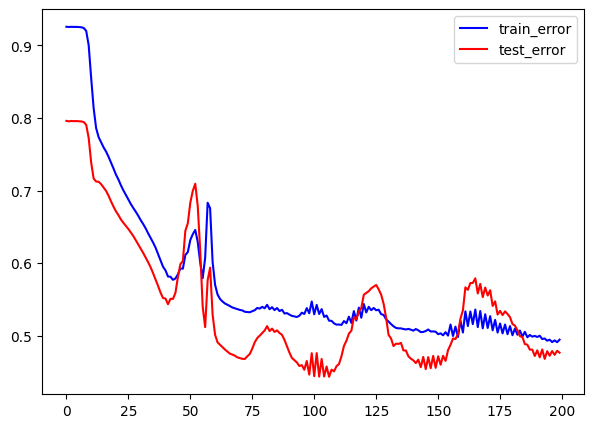

In [68]:
plt.figure(figsize = (7,5))
plt.plot(loss_history_train_L,'b',label='train_error')
plt.plot(loss_history_test_L,'r',label='test_error')
plt.legend()
plt.show()

In [ ]:
torch.save(model_L, './model/LSTM.pth')

In [ ]:
saved_xgb=pickle.dumps(xgb_model)
joblib.dump(xgb_model,'./xgb.pkl')

['./xbg.pkl']

In [84]:
saved_xgb=pickle.dumps(rf_model)
joblib.dump(rf_model,'./rf.pkl')

['./rf.pkl']